In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42)

adata = sc.read_h5ad("simCellsSpace/sim_cells_datasets_co_mo_simulated_classical.h5ad")
# Data prep
#sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
#sc.pp.log1p(adata)
adata.X = adata.layers['counts']
adata

AnnData object with n_obs × n_vars = 4000 × 120
    obs: 'cell_type'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [2]:
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)
#sc.experimental.pp.normalize_pearson_residuals(adata, theta=100, clip=True, inplace=True)

adata.X seems to be already log-transformed.


In [3]:
# Manual Targeted Setup
# We want to trace the flow:
# A (50) -> B (60 -> 70 -> 71, 72, 80) -> A (80 -> 90)

# Sources: The genes initiating signals or regulation
# The "Cause" List
gl_source = [
    "Gene_50", # Source from A 
    "Gene_90"  # Target in A (Spatial Feedback)
]

# The "Effect" List
gl_recv = [
    "Gene_60", # Target in B (Spatial)
    "Gene_70", # GRN in B (Internal)
    "Gene_71", # GRN in B (Internal)
    "Gene_72", # GRN in B (Internal)
    "Gene_80", # Soruce in B
]

In [4]:
adata.obs['cell_type'].unique()

['Type_A_Interact', 'Type_B_Lone', 'Type_A_Lone', 'Type_B_Interact']
Categories (4, object): ['Type_A_Interact', 'Type_A_Lone', 'Type_B_Interact', 'Type_B_Lone']

In [5]:
# This case we have 120 genes, but want to identify the functional ones!
from scipy.sparse import issparse

ict1 = (adata.obs["cell_type"] == 'Type_A_Interact') 
ict2 = (adata.obs["cell_type"] == 'Type_B_Interact') 

adata_ct1_co = adata[ict1, gl_source].copy()
adata_ct2_co = adata[ict2, gl_recv].copy()
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


AnnData object with n_obs × n_vars = 1000 × 2
    obs: 'cell_type'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1000 × 5
    obs: 'cell_type'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
CT1 (Co) mean expression: [0. 0.]
CT2 (Co) mean expression: [0. 0. 0. 0. 0.]


In [6]:
adata.obs['cell_type'].unique()

['Type_A_Interact', 'Type_B_Lone', 'Type_A_Lone', 'Type_B_Interact']
Categories (4, object): ['Type_A_Interact', 'Type_A_Lone', 'Type_B_Interact', 'Type_B_Lone']

In [7]:

ict1 = (adata.obs["cell_type"] == 'Type_A_Lone')
ict2 = (adata.obs["cell_type"] == 'Type_B_Lone') 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 1000 × 2
    obs: 'cell_type'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
View of AnnData object with n_obs × n_vars = 1000 × 5
    obs: 'cell_type'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


In [8]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

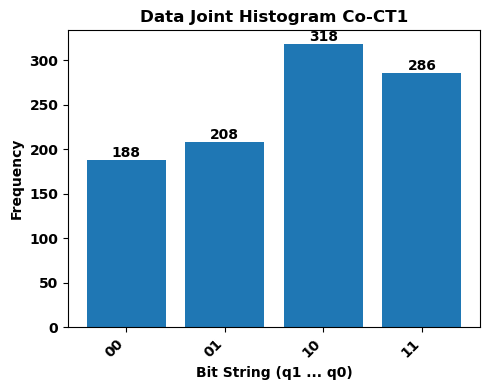

Joint Counts: Counter({'10': 318, '11': 286, '01': 208, '00': 188})
Bit Strings: ['00', '01', '10', '11']


In [9]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, 
                     figsize = (5,4),  title='Data Joint Histogram Co-CT1',
                     filename="co_ct1_ssim_histogram_dist.svg" )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

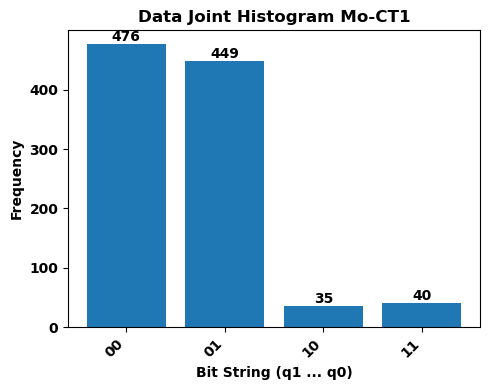

Joint Counts: Counter({'00': 476, '01': 449, '11': 40, '10': 35})
Bit Strings: ['00', '01', '10', '11']


In [10]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, 
                     figsize = (5,4), title='Data Joint Histogram Mo-CT1', 
                     filename="mo_ct1_ssim_histogram_dist.svg"
                     )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

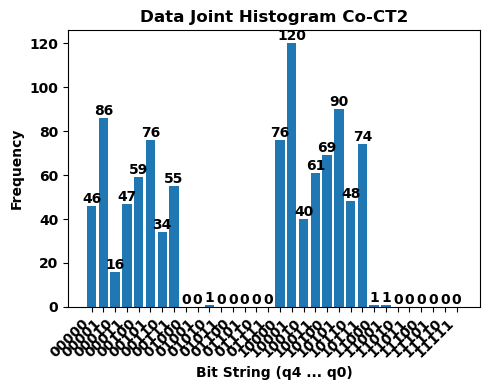

Joint Counts: Counter({'10001': 120, '10101': 90, '00001': 86, '10000': 76, '00101': 76, '10111': 74, '10100': 69, '10011': 61, '00100': 59, '00111': 55, '10110': 48, '00011': 47, '00000': 46, '10010': 40, '00110': 34, '00010': 16, '11001': 1, '01010': 1, '11000': 1})
Bit Strings: ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01010', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001']


In [11]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, 
                     figsize = (5,4), title='Data Joint Histogram Co-CT2', 
                     filename="co_ct2_ssim_histogram_dist.svg")  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

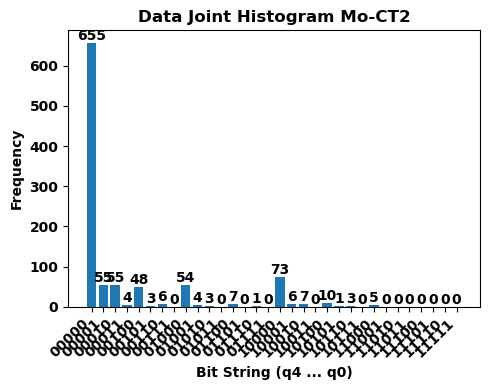

Joint Counts: Counter({'00000': 655, '10000': 73, '00001': 55, '00010': 55, '01000': 54, '00100': 48, '10100': 10, '10010': 7, '01100': 7, '00110': 6, '10001': 6, '11000': 5, '01001': 4, '00011': 4, '10110': 3, '01010': 3, '00101': 3, '01110': 1, '10101': 1})
Bit Strings: ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '01000', '01001', '01010', '01100', '01110', '10000', '10001', '10010', '10100', '10101', '10110', '11000']


In [12]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, 
                     figsize = (5,4), title='Data Joint Histogram Mo-CT2', 
                     filename="mo_ct2_ssim_histogram_dist.svg"
                     )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [13]:
from quantum_functions import vector_normalize_dictionary_values, create_initial_circuit2

import numpy as np
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set CT1 Mo (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set CT2 Mo (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set CT1 Co (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set CT2 Co (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'00': 476, '01': 449, '11': 40, '10': 35})
State Set CT2 MO: Counter({'00000': 655, '10000': 73, '00001': 55, '00010': 55, '01000': 54, '00100': 48, '10100': 10, '10010': 7, '01100': 7, '00110': 6, '10001': 6, '11000': 5, '01001': 4, '00011': 4, '10110': 3, '01010': 3, '00101': 3, '01110': 1, '10101': 1})
Interacted State Set CT1 CO: Counter({'10': 318, '11': 286, '01': 208, '00': 188})
Interacted State Set CT2 CO: Counter({'10001': 120, '10101': 90, '00001': 86, '10000': 76, '00101': 76, '10111': 74, '10100': 69, '10011': 61, '00100': 59, '00111': 55, '10110': 48, '00011': 47, '00000': 46, '10010': 40, '00110': 34, '00010': 16, '11001': 1, '01010': 1, '11000': 1})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set CT1 Mo (Vector Norm): {'01': 0.683922195580437, '00': 0.7250489200362762, '10': 0.053312420590902666, '11': 0.06092848067531733}
Normalized State Set CT2 Mo (Vector Norm): {'10000': 0.109311327

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.



--- Topology Test Results ---
CNOTs applied: [(0, 2), (2, 3), (3, 4), (3, 6), (6, 1)]
KL Div (Circ 1): 1.012953
KL Div (Circ 2): 2.431023
Total Combined KL: 3.443976


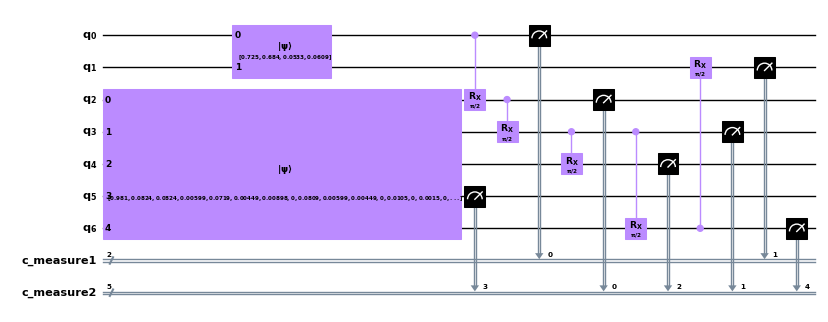

In [14]:
from quantum_functions import concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit, score_circuit_kl_divergences

def test_specific_topology(
    circ1, 
    circ2, 
    cnot_topology, 
    state_vec_probs_target1, 
    state_vec_probs_target2, 
    nshots=5000
):
    """
    Manually injects a specific CNOT topology and evaluates the KL divergence.
    """
    ng_circ1 = circ1.num_qubits
    
    # 1. Concatenate the two base circuits
    base_combined = concatenate_circuits_with_separate_measurements(circ1, circ2)
    
    # 2. Add your specific CNOTs and the measurement gates
    # Note: Using your existing 'add_cnots_and_measurements_to_circuit'
    circuit_to_test = add_cnots_and_measurements_to_circuit(
        base_combined, 
        ng_circ1, 
        cnot_topology
    )
    
    # 3. Score it
    kl_div1, kl_div2 = score_circuit_kl_divergences(
        circuit_to_test,
        state_vec_probs_target1,
        state_vec_probs_target2,
        nshots
    )
    
    total_kl = kl_div1 + kl_div2 if kl_div1 is not None and kl_div2 is not None else float('inf')
    
    print(f"\n--- Topology Test Results ---")
    print(f"CNOTs applied: {cnot_topology}")
    print(f"KL Div (Circ 1): {kl_div1:.6f}")
    print(f"KL Div (Circ 2): {kl_div2:.6f}")
    print(f"Total Combined KL: {total_kl:.6f}")
    
    return circuit_to_test, total_kl


# Define your "Ground Truth" or "Expected" topology
#my_expected_topology = [(0, 2), (2, 3), (3, 4), (3, 5), (3, 6), (6, 1)] 
#my_expected_topology = [(0, 2), (2, 3), (3, 6), (6, 1)] 
my_expected_topology = [(0, 2), (2, 3), (3, 4), (3, 6), (6, 1)]
# Run the test
final_circ, score = test_specific_topology(
    circ1, 
    circ2, 
    my_expected_topology,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co
)

final_circ.draw(output="mpl", style="clifford", fold=40, scale=0.5, #filename="cnot_optimized_circuit_classi.svg"
                               )


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'00': 2612, '01': 2160, '11': 191, '10': 37}
Counts for c_measure2: {'00000': 3672, '00011': 134, '00001': 600, '10011': 155, '10111': 168, '00111': 132, '11010': 1, '00101': 5, '10000': 50, '10010': 8, '10001': 9, '01001': 7, '11011': 2, '01000': 22, '10110': 3, '00110': 9, '00010': 6, '00100': 15, '11111': 2}


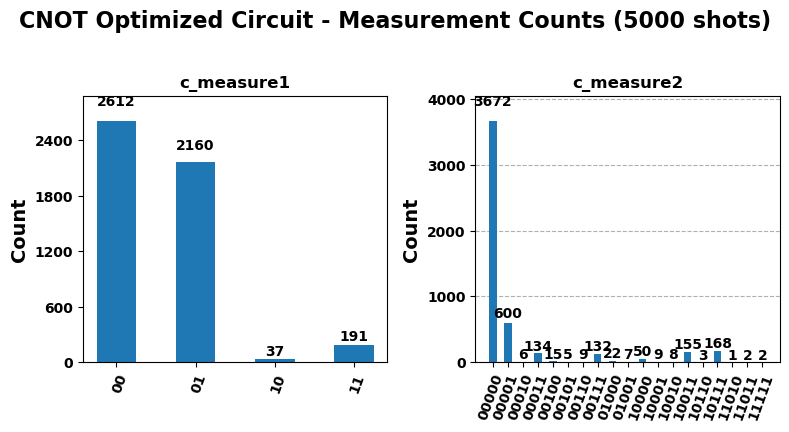

In [15]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_circ, nshots=5000, 
                            title_prefix="CNOT Optimized Circuit", figsize=(8,4.5), 
                            #figure_save_name = "cnot_optimized_circuit_histograms.svg" 
                            )

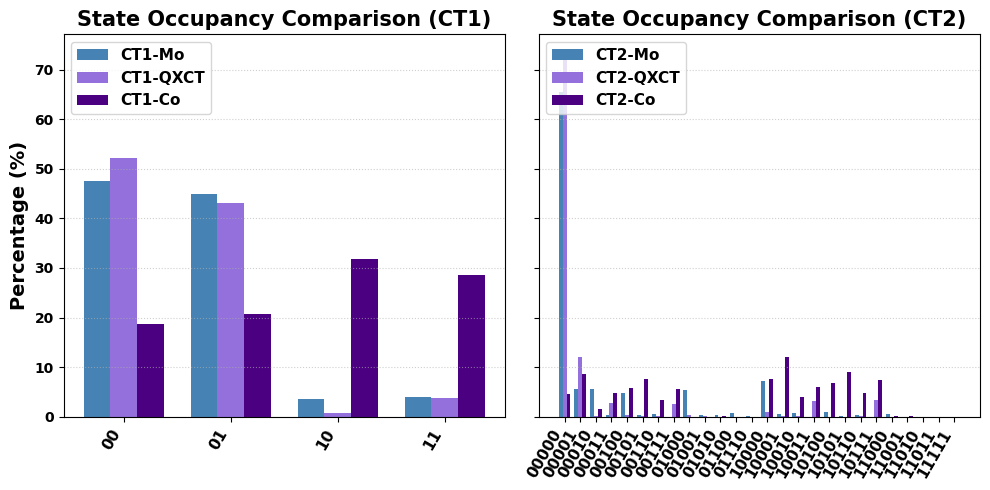

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (5 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['3.1416', '1.7344', '1.9049', '2.8898', '2.5018']
CRX Angle Optimization took: 14.18 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1416', '1.7344', '1.9049', '2.8898', '2.5018']
  Minimum Combined KL Divergence with Optimized CRX: 2.530336


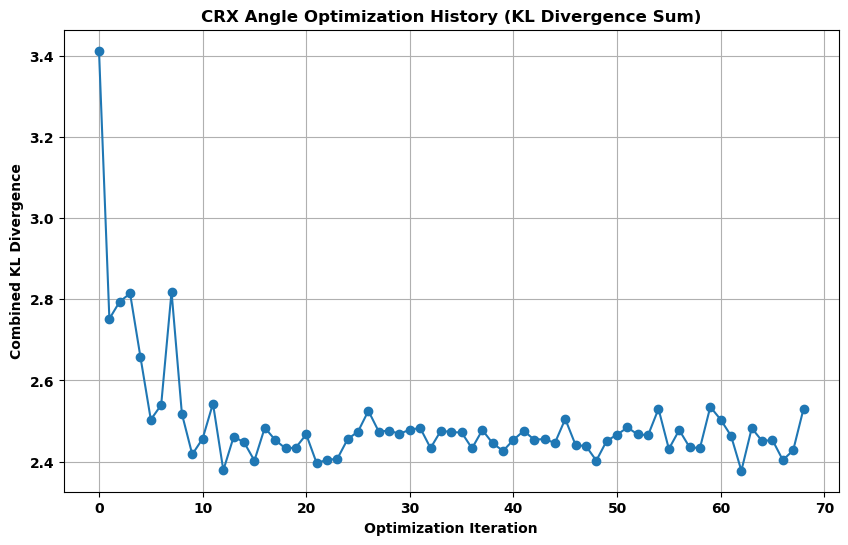


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 2/»
              »
c_measure2: 5/»
              »
«                                                                                                   ┌────────────────────────────────────────────────┐                                                                                     »
«         q_0: ─────────────────────────────────────────────────────────────────────────────────────┤0                                               ├─────────────────────────────────────────────────────────────────────────────────────»
«                                                                                                   │  Initialize(0.72505,0.68392,0.053312,0.060928) │                          

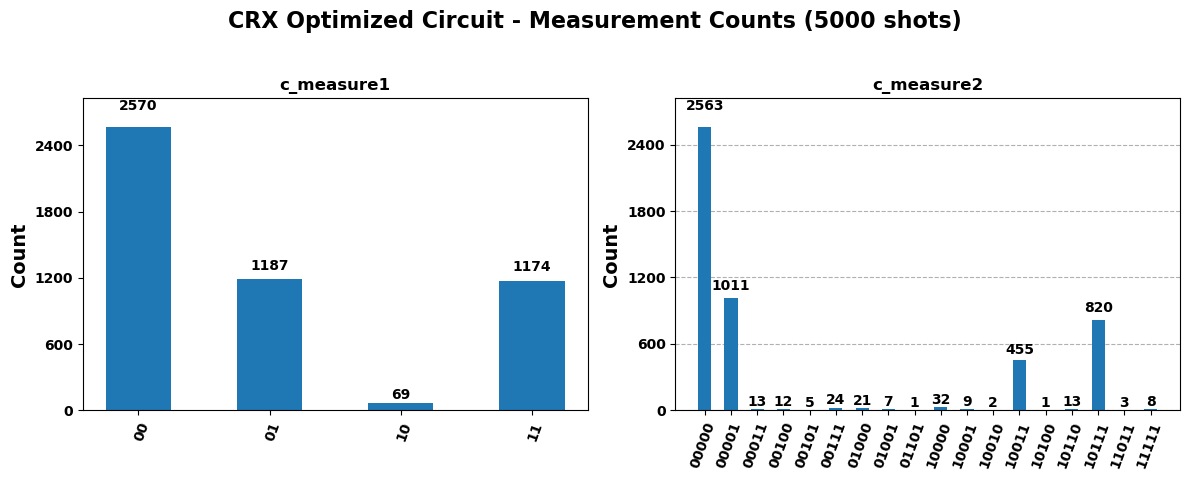

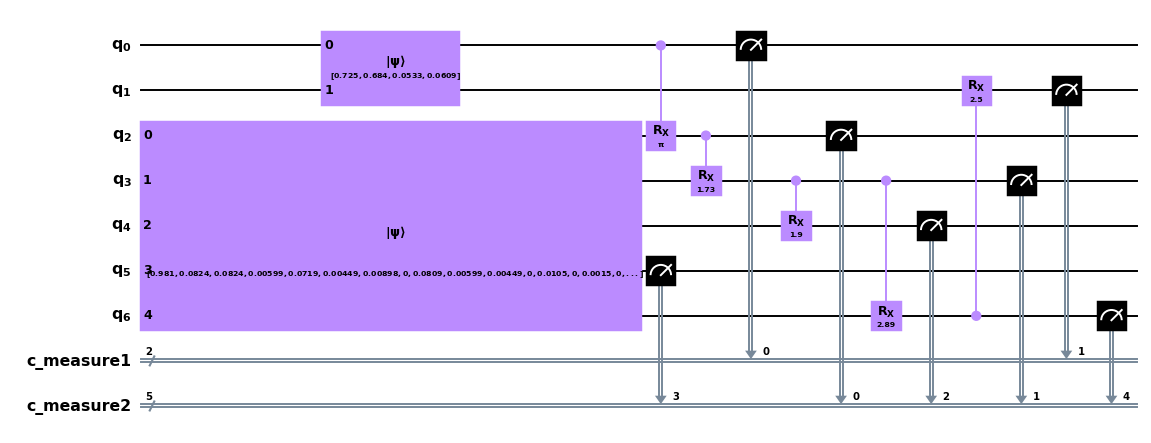

In [17]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    my_expected_topology, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    my_expected_topology,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7)

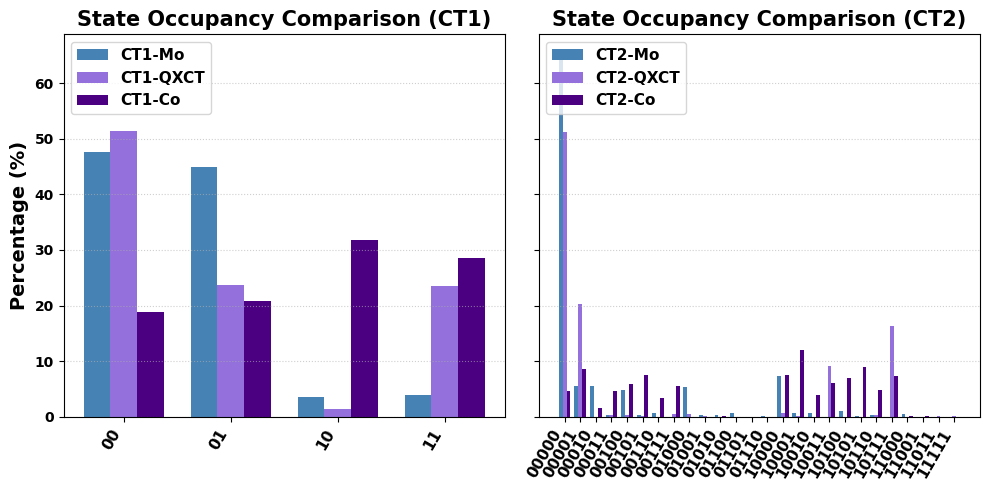

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
#plt.savefig('state_occupancy_comparison.svg')
plt.show()

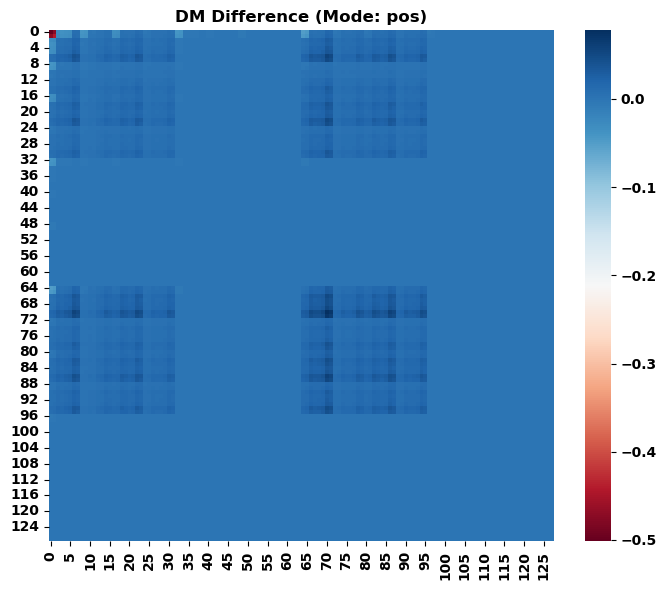


--- CNOT Analysis (pos) ---
Max Signal: 0.0778
Candidates Found: 30 / 42
------------------------------

{'max_element': 0.0778128287408508, 'min_element': -0.5017139607115434, 'abs_average': 0.0034456896686433924, 'relevant_avg': 0.00943815211732506}


In [19]:
from quantum_functions import find_cnot_candidates_from_state_diff
thresh = 0.01
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, search_mode="pos", show_plot = True, verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


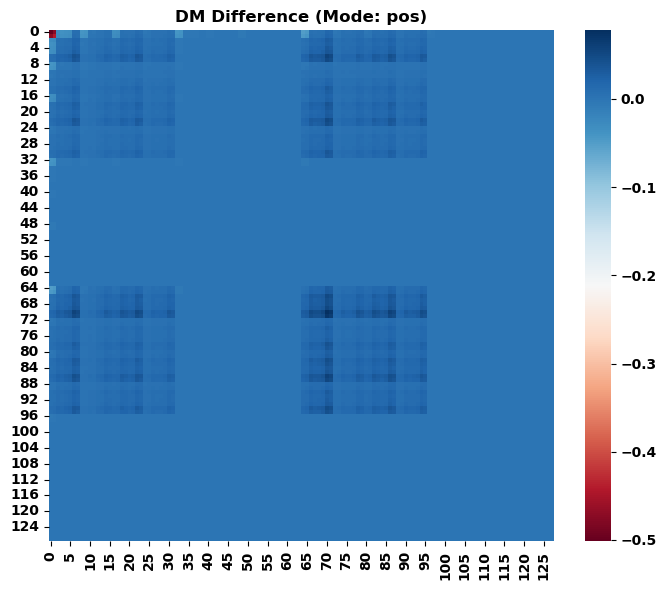


--- CNOT Analysis (pos) ---
Max Signal: 0.0778
Candidates Found: 30 / 42
------------------------------

Number of initial CNOT candidates: 30
Initial KL-divergence: 4.546683

  - Starting Efficiency-Optimized Search -

--- Iteration 1 | Current KL: 4.576976 ---
   - Single Insertion Phase: Added (0, 2) at index 0. New KL: 3.811746
  [Phase 1] Added Single: (0, 2) | New KL: 3.811746
  [Phase 2] Added Pair: ((0, 1), (0, 6)) | New KL: 2.713265

--- Iteration 2 | Current KL: 2.713265 ---
   - Single Insertion Phase: Added (0, 4) at index 0. New KL: 2.203896
  [Phase 1] Added Single: (0, 4) | New KL: 2.203896
  [Phase 2] Added Pair: ((0, 3), (1, 0)) | New KL: 1.985127

--- Iteration 3 | Current KL: 1.985127 ---
   - Single Insertion Phase: Added (1, 2) at index 3. New KL: 1.863698
  [Phase 1] Added Single: (1, 2) | New KL: 1.863698
  [Phase 2] Added Pair: ((4, 0), (4, 1)) | New KL: 1.753226
   - Deletion Phase: Best Removed (1, 0). New KL: 1.801133

--- Iteration 4 | Current KL: 1.753226 

In [20]:
from quantum_functions import find_best_cnot_sequence_iterative_n_wise, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

# Single insertion can be insertion or deletation of CX (something failing with the update criteria)
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    nchoose=2,
    kl_tol = 0.1, 
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'10': 998, '11': 519, '01': 769, '00': 2714}
Counts for c_measure2: {'00111': 242, '00001': 235, '00101': 220, '10001': 207, '10111': 192, '00000': 2565, '10011': 222, '00100': 100, '10100': 92, '10101': 201, '00110': 78, '00011': 235, '10000': 126, '10010': 90, '10110': 72, '00010': 91, '11011': 3, '01000': 16, '01101': 3, '01111': 2, '11001': 2, '11101': 2, '01001': 1, '11111': 1, '01011': 1, '01010': 1}


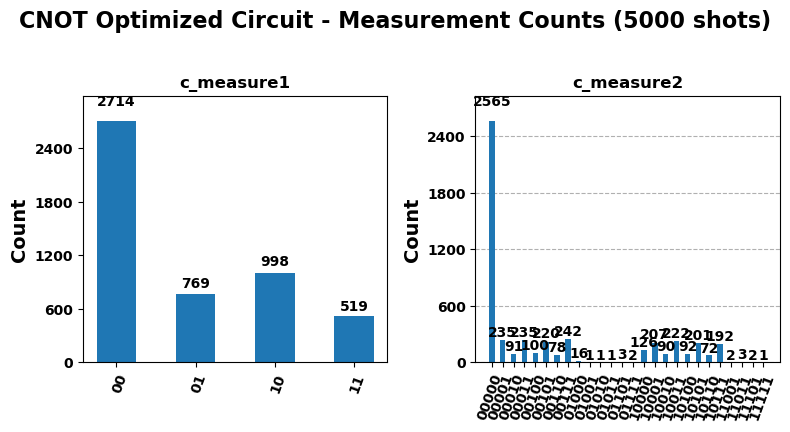

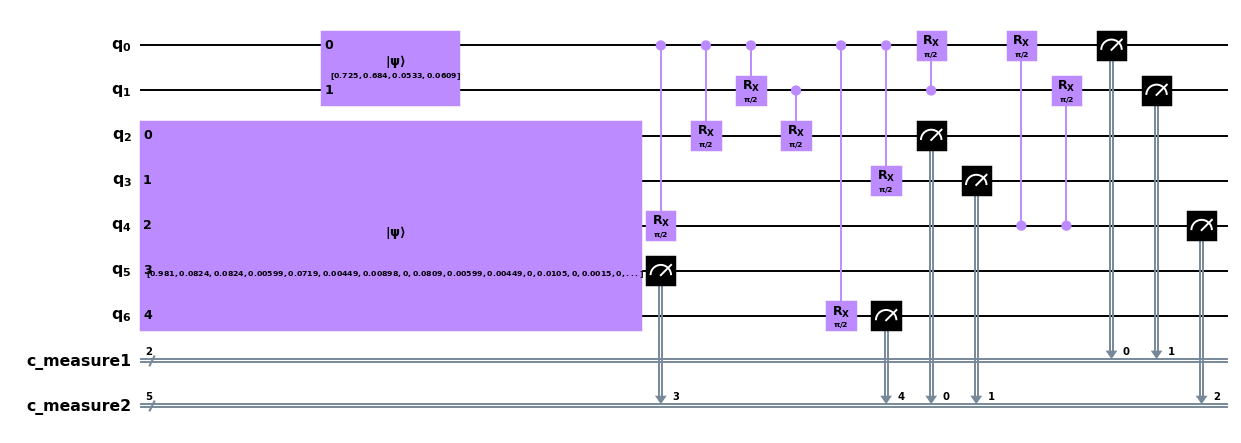

In [21]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, 
                            title_prefix="CNOT Optimized Circuit", figsize=(8,4.5), 
                            #figure_save_name = "cnot_optimized_circuit_histograms.svg" 
                            )
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.7, #filename="cnot_optimized_circuit_classi.svg"
                               )

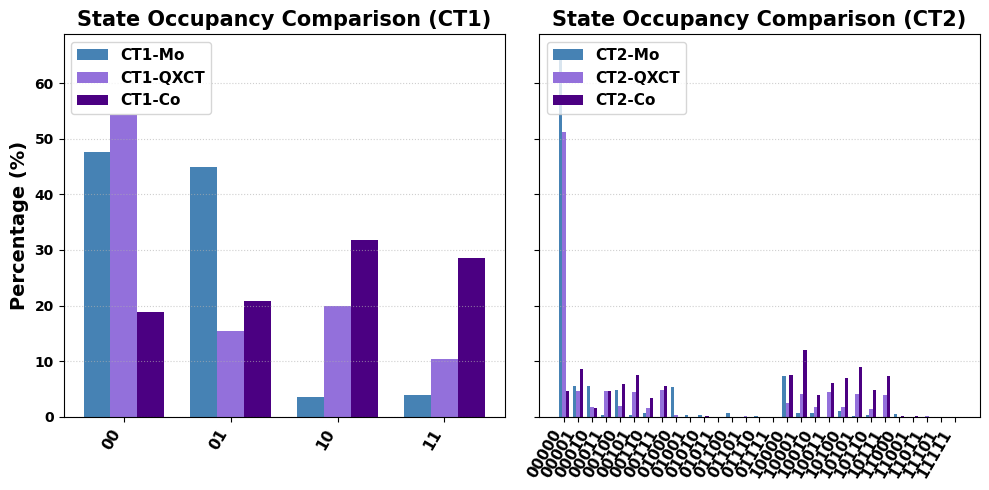

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (9 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.8000', '1.6630', '1.5576', '1.5570', '1.5686', '1.5585', '1.5472', '1.5657', '1.5518']
CRX Angle Optimization took: 20.86 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.8000', '1.6630', '1.5576', '1.5570', '1.5686', '1.5585', '1.5472', '1.5657', '1.5518']
  Minimum Combined KL Divergence with Optimized CRX: 1.896890


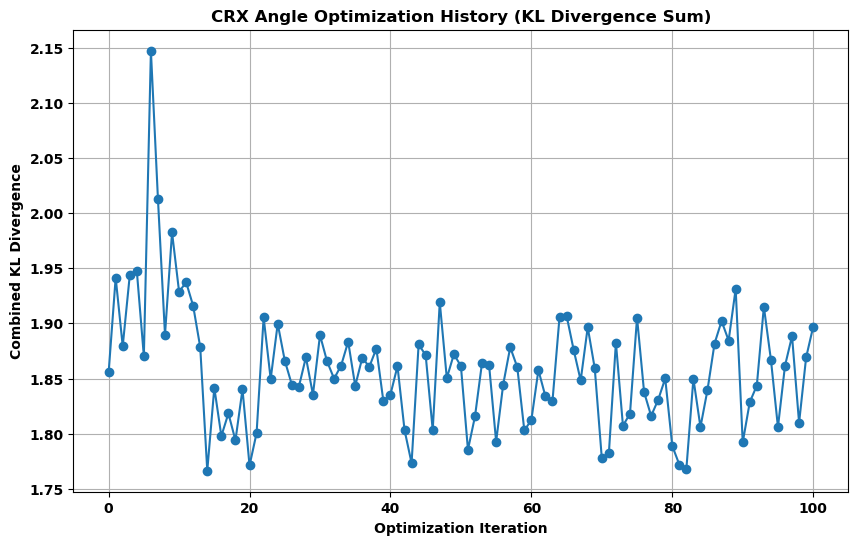


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 2/»
              »
c_measure2: 5/»
              »
«                                                                                                   ┌────────────────────────────────────────────────┐                                                                                     »
«         q_0: ─────────────────────────────────────────────────────────────────────────────────────┤0                                               ├─────────────────────────────────────────────────────────────────────────────────────»
«                                                                                                   │  Initialize(0.72505,0.68392,0.053312,0.060928) │                          

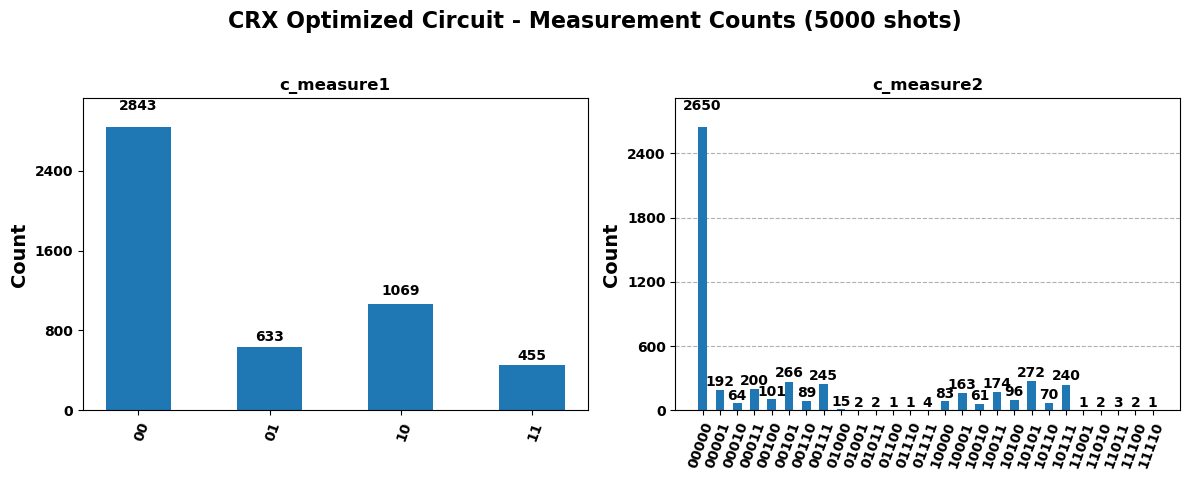

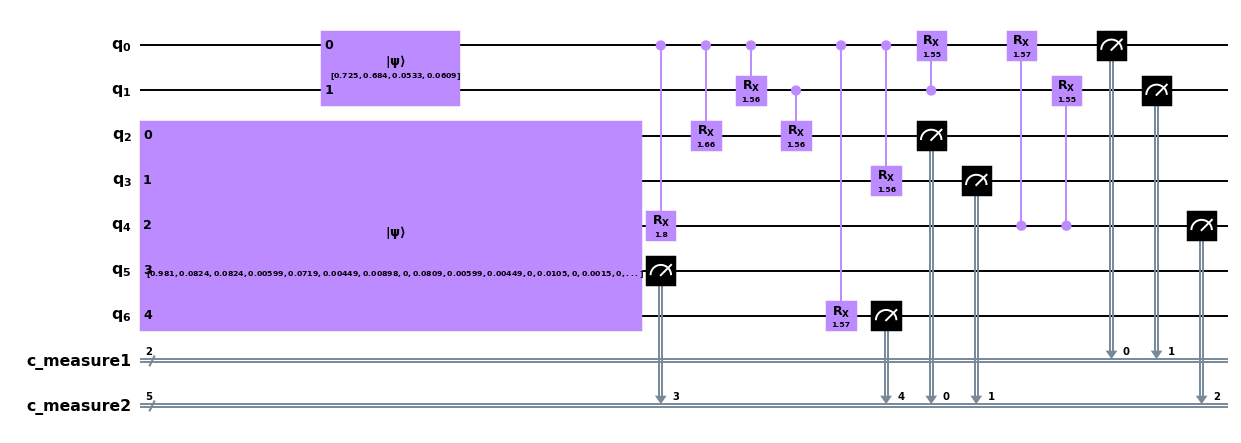

In [24]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.7)

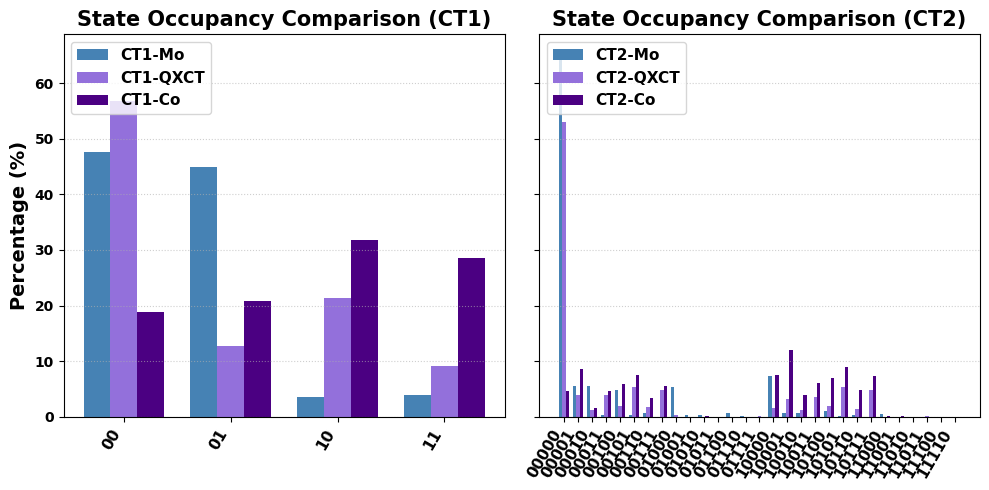

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt.svg')
plt.show()


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---

--- Generating CNOT candidates from density matrix difference. ---


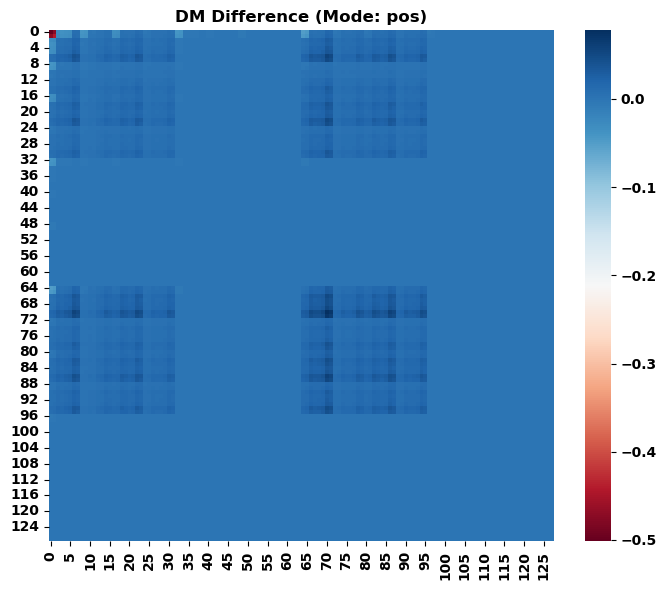


--- CNOT Analysis (pos) ---
Max Signal: 0.0778
Candidates Found: 30 / 42
------------------------------

Initial KL divergence (baseline): 4.572634

--- Starting Epoch 1/30 (Addition) with CNOT: (3, 1) (KL: 4.549430) ---
    --> Found a better KL on this path: 3.742514 at depth 2 with added CNOT (0, 2)
    --> Found a better KL on this path: 3.089652 at depth 3 with added CNOT (0, 6)
    --> Found a better KL on this path: 2.631487 at depth 4 with added CNOT (0, 1)
    --> Found a better KL on this path: 2.297203 at depth 5 with added CNOT (0, 4)
    --> Found a better KL on this path: 2.092683 at depth 6 with added CNOT (1, 0)
    --> Found a better KL on this path: 1.970885 at depth 7 with added CNOT (1, 3)
    --> Found a better KL on this path: 1.865139 at depth 8 with added CNOT (1, 6)
    --> Found a better KL on this path: 1.848059 at depth 9 with added CNOT (2, 6)
  Epoch 1 best KL Sum: 1.848059
  --> Epoch 1 found a new overall best KL Sum: 1.848059

--- Starting Greedy CNOT 

In [27]:
from quantum_functions import find_best_cnot_sequence_multi_epoch

np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 42
min_greedy_depth = 2

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold = thresh,
    search_mode="pos",
    kl_tol = 0.1,
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'11': 1124, '00': 2614, '10': 575, '01': 687}
Counts for c_measure2: {'10010': 154, '00000': 2592, '10000': 126, '10011': 75, '00111': 188, '10101': 234, '00011': 242, '00101': 307, '10100': 117, '10001': 275, '00001': 277, '10111': 77, '00110': 42, '10110': 122, '00010': 63, '00100': 72, '01000': 22, '01101': 3, '11101': 3, '01100': 1, '01011': 2, '01110': 1, '01010': 1, '11110': 1, '01001': 1, '11010': 1, '11001': 1}


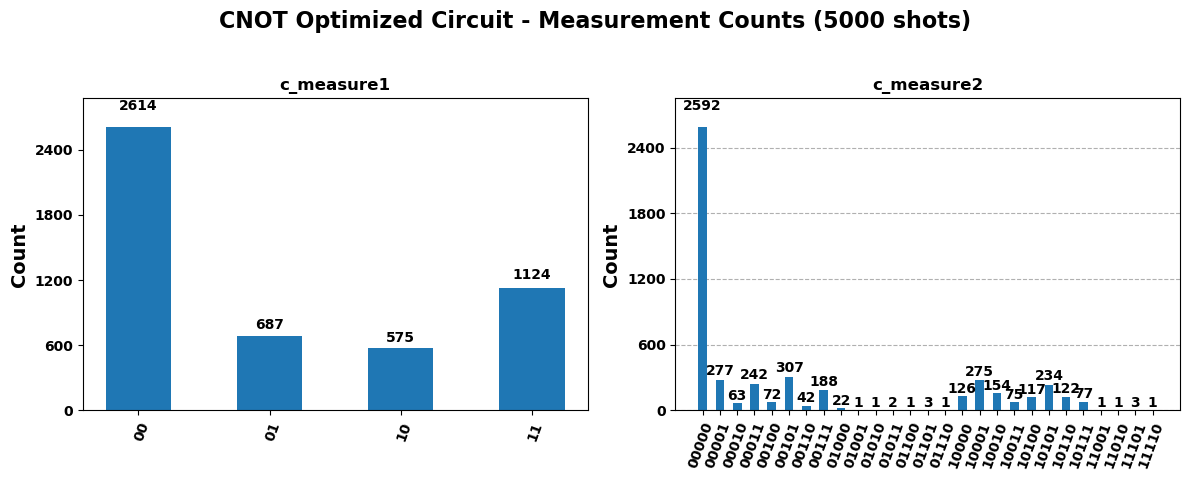

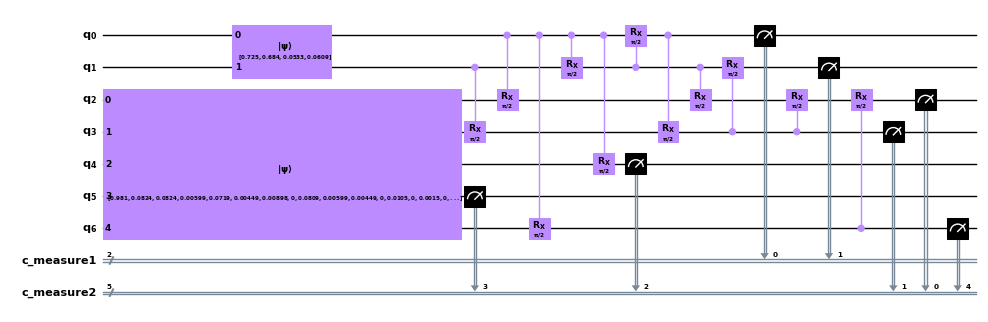

In [28]:
from quantum_functions import plot_measurement_histograms

measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

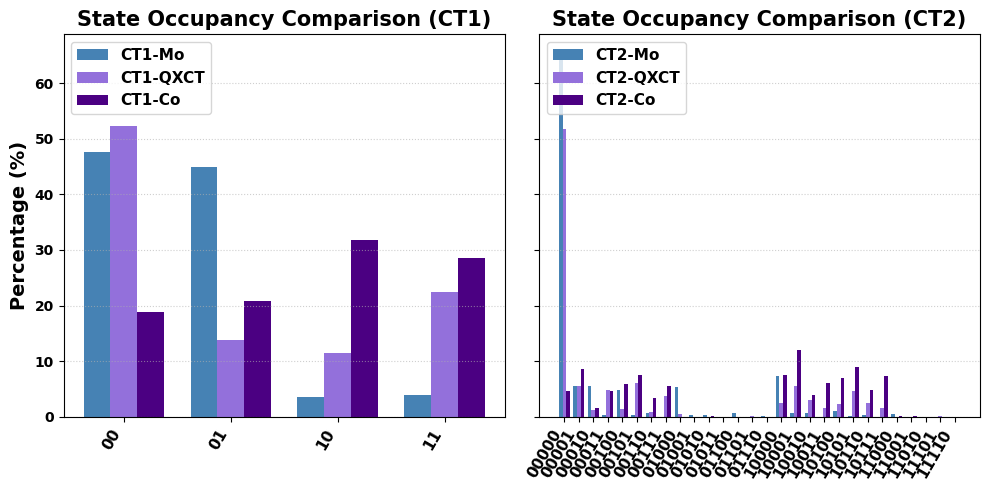

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison.svg')
plt.show()


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (11 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.5708', '1.5708', '2.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708']
CRX Angle Optimization took: 23.58 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.5708', '1.5708', '2.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708', '1.5708']
  Minimum Combined KL Divergence with Optimized CRX: 1.819379


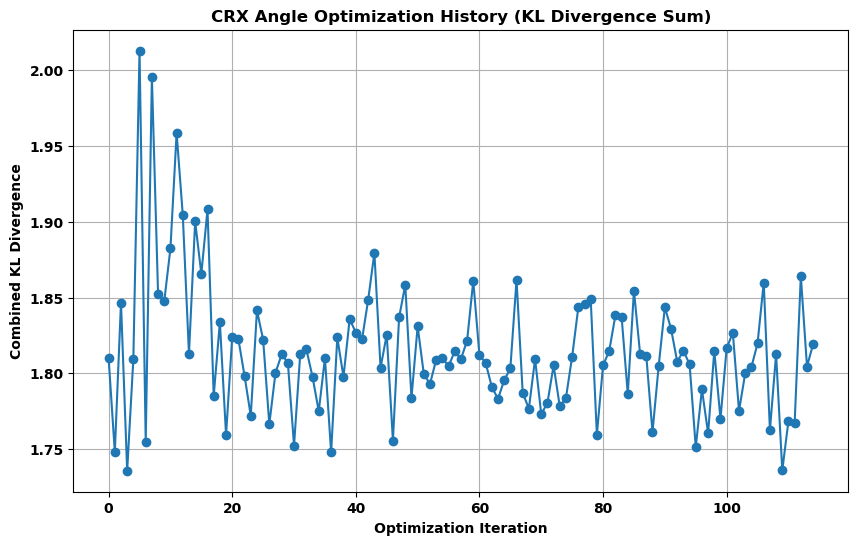


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 2/»
              »
c_measure2: 5/»
              »
«                                                                                                   ┌────────────────────────────────────────────────┐                                                                                     »
«         q_0: ─────────────────────────────────────────────────────────────────────────────────────┤0                                               ├─────────────────────────────────────────────────────────────────────────────────────»
«                                                                                                   │  Initialize(0.72505,0.68392,0.053312,0.060928) │                          

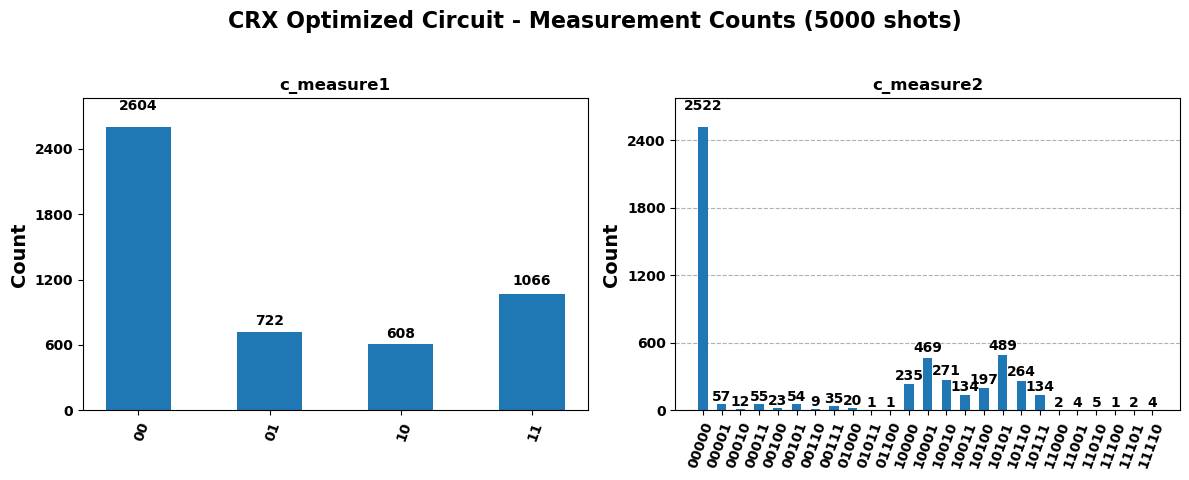

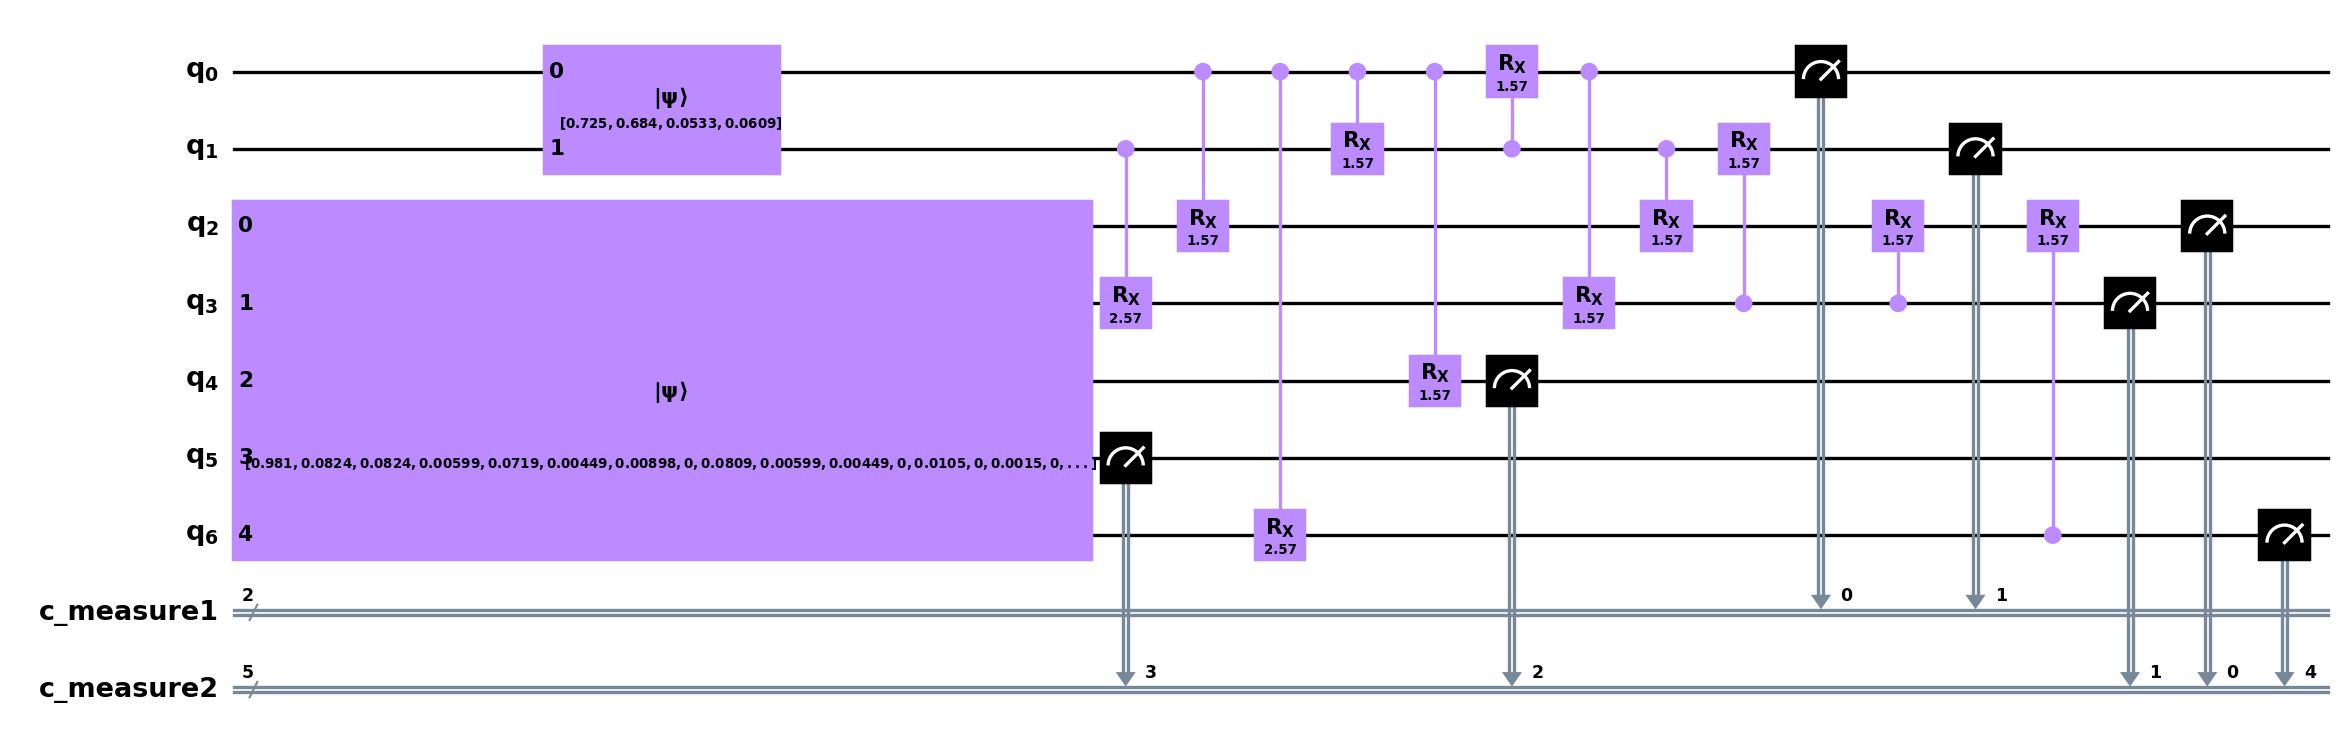

In [30]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=1.2)

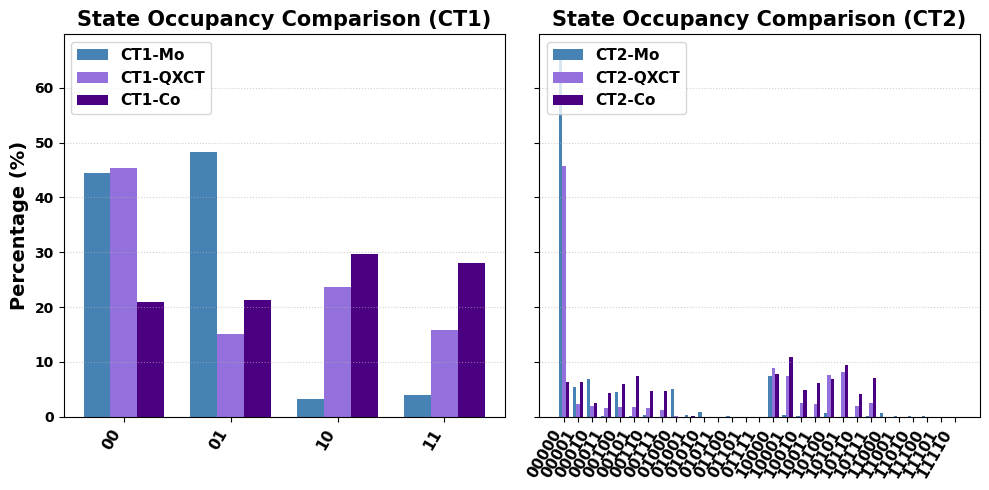

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Normalization Logic ---
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize your raw data
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# --- 2. Data Structuring ---
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# --- 3. Formatting & Style Constants ---
color_mo = '#4682B4'    # Darker Steel Blue
color_qxct = '#9370DB'  # Medium Purple
color_co = '#4B0082'    # Deep Indigo

legend_map = {
    'joint_counts_ct1_mo': 'CT1-Mo',
    'joint_counts_ct2_mo': 'CT2-Mo',
    'joint_counts_ct1_co': 'CT1-Co',
    'joint_counts_ct2_co': 'CT2-Co',
    'measure_counts1': 'CT1-QXCT',
    'measure_counts2': 'CT2-QXCT'
}

# --- 4. Plotting ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Ensure all bitstrings are present on the X-axis
    all_keys = sorted(list(set(current_data[0].keys()) | 
                           set(current_data[1].keys()) | 
                           set(current_data[2].keys())))
    
    x = np.arange(len(all_keys))
    width = 0.25 
    
    # Extract values for bars
    values_mo = [current_data[0].get(key, 0) for key in all_keys]   # Initial
    values_qxct = [current_data[1].get(key, 0) for key in all_keys] # Prediction
    values_co = [current_data[2].get(key, 0) for key in all_keys]   # Target

    # Bar plotting
    axes[i].bar(x - width, values_mo, width, 
                label=legend_map[current_titles[0]], color=color_mo)
    axes[i].bar(x, values_qxct, width, 
                label=legend_map[current_titles[1]], color=color_qxct)
    axes[i].bar(x + width, values_co, width, 
                label=legend_map[current_titles[2]], color=color_co)
    
    # Refined Axis Customization
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=60, ha='right', fontsize=11)
    
    cell_type = "CT1" if i == 0 else "CT2"
    axes[i].set_title(f'State Occupancy Comparison ({cell_type})', fontweight='bold', fontsize=15)
    
    axes[i].grid(axis='y', linestyle=':', alpha=0.6)
    
    if i == 0:
        axes[i].set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
    
    axes[i].legend(frameon=True, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('state_occupancy_comparison_ang_opt.svg')
plt.show()


--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


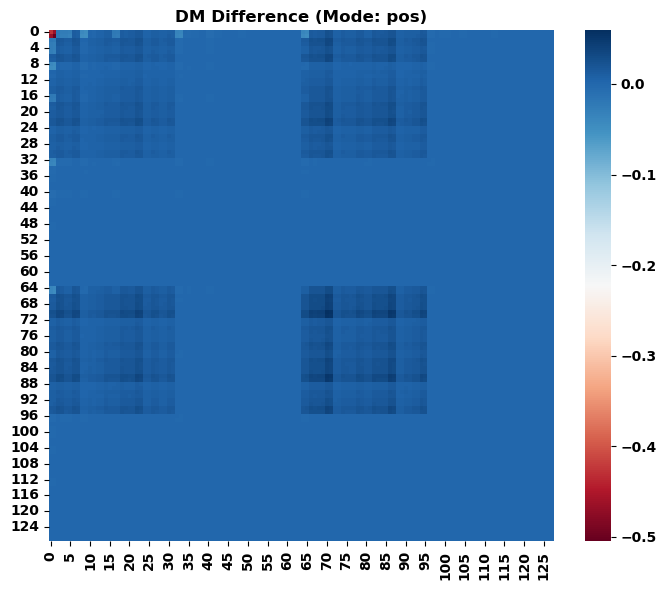


--- CNOT Analysis (pos) ---
Max Signal: 0.0592
Candidates Found: 30 / 42
------------------------------

Initial KL Divergence (no CNOTs): 3.701300

--- Building KL Divergence Matrix (30x30) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 870
--- KL Divergence Matrix Built ---


In [ ]:
from quantum_functions import build_kl_divergence_matrix_interaction

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)

kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_interaction(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh, 
    search_mode="pos",
    include_single_cnot_kl=True
)

In [31]:
from quantum_functions import kl_to_qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [32]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-7.165314516138689
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIZIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIZIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIZIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIZIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIZIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIZIIIIIIIIIIIIIZ', 'IIIIIIIIIIIII

In [33]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
#expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_47796\2260493373.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


Starting optimization with method: COBYLA
Iteration 0: Current cost: 0.22391159316477316
Iteration 20: Current cost: 0.013260511662107679
Iteration 40: Current cost: 0.05088214356163598
Iteration 60: Current cost: -6.523851079921254
Iteration 80: Current cost: -6.236889275561749
Iteration 100: Current cost: -6.5039693788916
Iteration 200: Current cost: -8.224213196591

Optimization Result:
 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -8.296772017711804
       x: [ 1.024e+00  2.222e+00 ...  1.422e+00  1.365e+00]
    nfev: 200
   maxcv: 0.0

Final Energy: -8.296772017711804

Optimized Full Parameters:
  θ[0]: 1.0241579428353564
  θ[1]: 2.2220822437111507
  θ[2]: 2.4652009861987696
  θ[3]: 1.8398596449182472
  θ[4]: 1.6787881271745397
  θ[5]: 1.8321220698475875
  θ[6]: 1.660507790672385
  θ[7]: 1.7885375025107706
  θ[8]: 1.736830131834275
  θ[9]: 1.588425806155813
  θ[10]: 1.6396474328771633
  θ[11]: 1.6652724250209627
  θ[12]: 

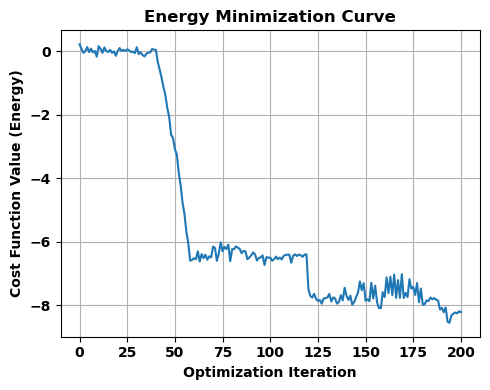

In [34]:
from quantum_functions import vqe_solver
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()

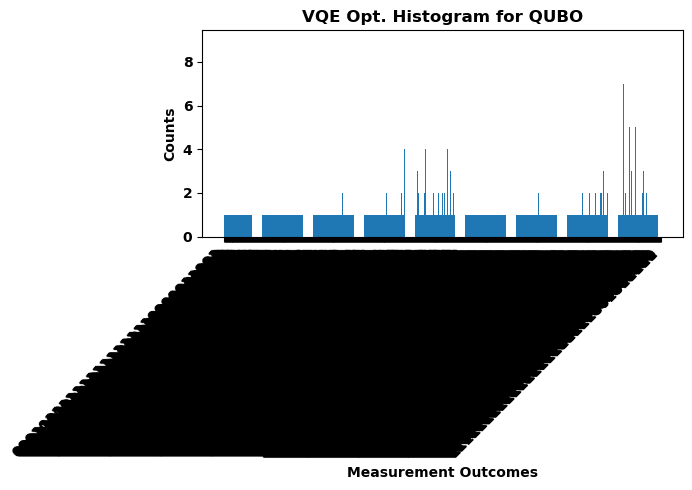

In [35]:
from quantum_functions import evaluate_and_plot_ansatz

counts, bound_circuit = evaluate_and_plot_ansatz(
    ansatz=expanded_ansatz, 
    params=optimized_params, 
    backend=backend,
    shots=1024,
    title="VQE Opt. Histogram for QUBO",
    show_plot=True  # Explicitly show the plot
)
#bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [36]:
# ==============================================================================
# --- CALL THE VQE HYBRID SEARCH AND DISPLAY RESULTS ---
# ==============================================================================
from quantum_functions import run_vqe_hybrid_search
# Assume these variables are defined from your previous notebook cells:
# - counts: The dictionary of measurement results from your VQE run.
# - initial_cnot_config: The full list of CNOT candidates used for the VQE QUBO.
# - circ1, circ2: Your two base quantum circuits.
# - normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo: Initial states.
# - normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co: Target states.
# - thresh: The threshold for density matrix analysis (if used).

# Call the main search function
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=counts,
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,
    nshots=5000,
    threshold=thresh,
    search_mode="pos",
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30
)

# --- FINAL SUMMARY: Display the Overall Best Solution ---
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the VQE's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    # Re-create and draw the final, absolute best circuit
    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No VQE solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")

--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 25 CNOTs:
  q[0] -> q[2]
  q[0] -> q[4]
  q[0] -> q[6]
  q[1] -> q[3]
  q[1] -> q[4]
  q[1] -> q[6]
  q[2] -> q[0]
  q[2] -> q[1]
  q[2] -> q[3]
  q[2] -> q[4]
  q[2] -> q[6]
  q[3] -> q[0]
  q[3] -> q[1]
  q[3] -> q[2]
  q[3] -> q[4]
  q[3] -> q[6]
  q[4] -> q[0]
  q[4] -> q[1]
  q[4] -> q[2]
  q[4] -> q[3]
  q[4] -> q[6]
  q[6] -> q[0]
  q[6] -> q[1]
  q[6] -> q[2]
  q[6] -> q[4]

Setting number of greedy search epochs to 25 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 25
Initial KL divergence (baseline): 3.729584

--- Starting Epoch 1/25 (Addition) with CNOT: (4, 2) (KL: 3.749674) ---
  Skipping epoch: Single CNOT KL (3.749674) does not improve over baseline (3.729584).

--- Starting Epoch 2/25 (Addition) 


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'00': 2424, '11': 867, '01': 1217, '10': 492}
Counts for c_measure2: {'00000': 2605, '10010': 98, '00101': 173, '00111': 175, '10001': 410, '10110': 177, '10100': 278, '10000': 262, '10101': 228, '10111': 80, '00100': 138, '10011': 52, '00110': 58, '00001': 166, '00011': 50, '00010': 24, '11000': 3, '11100': 4, '01000': 12, '11010': 2, '11111': 1, '11001': 2, '01100': 1, '01101': 1}


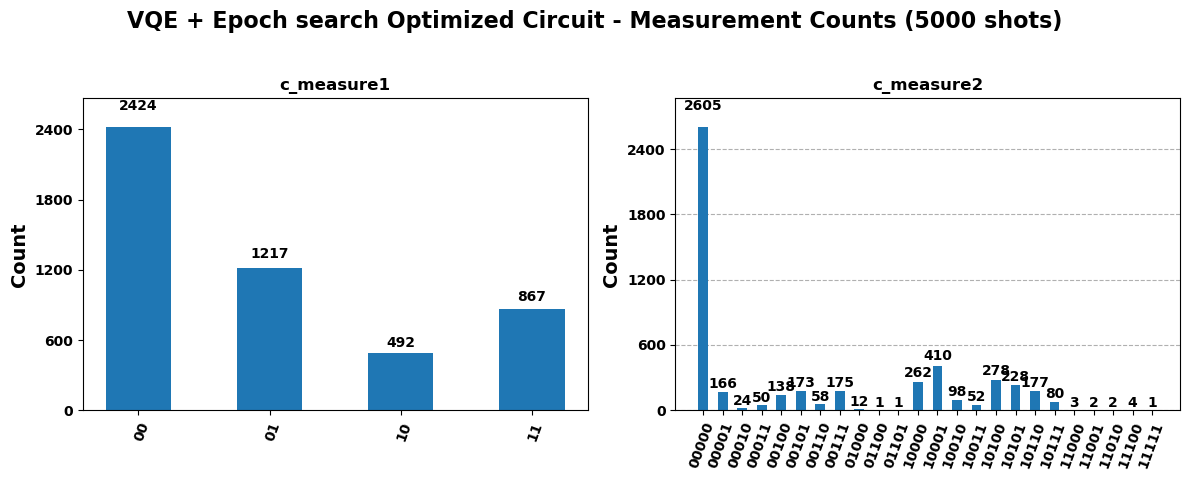

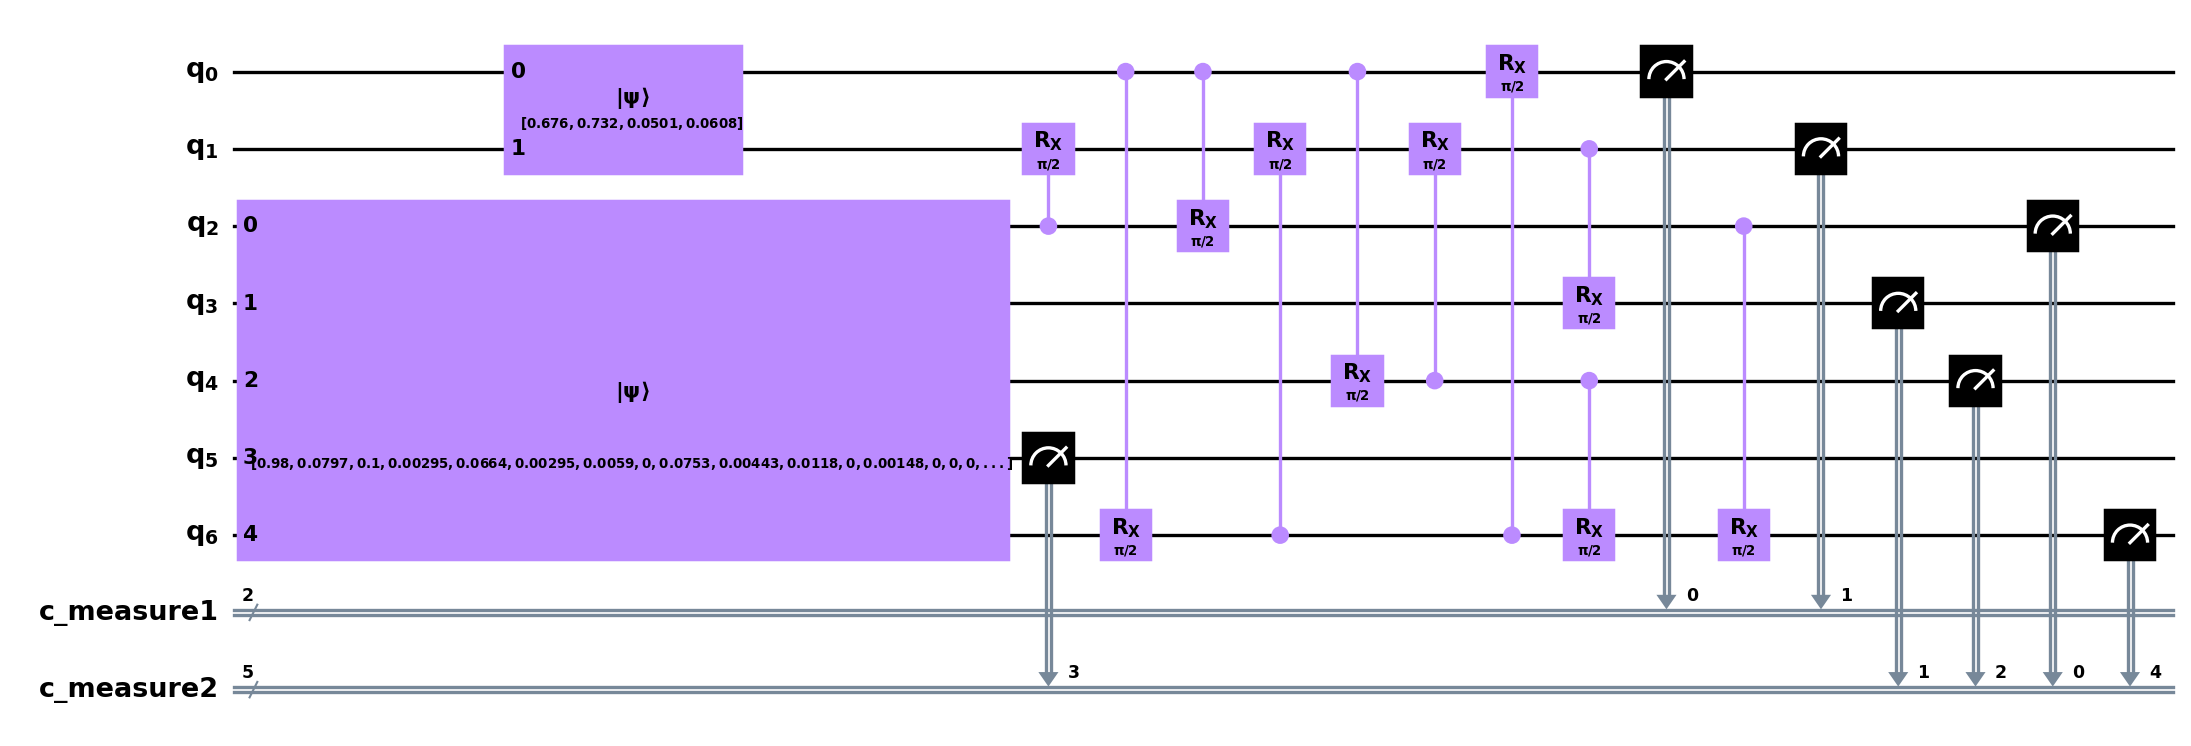

In [37]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=1.2)


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (10 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['1.7553', '2.7631', '1.5161', '1.4478', '1.5974', '1.5605', '1.4112', '1.4566', '2.5744', '1.5654']
CRX Angle Optimization took: 25.10 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['1.7553', '2.7631', '1.5161', '1.4478', '1.5974', '1.5605', '1.4112', '1.4566', '2.5744', '1.5654']
  Minimum Combined KL Divergence with Optimized CRX: 1.117821


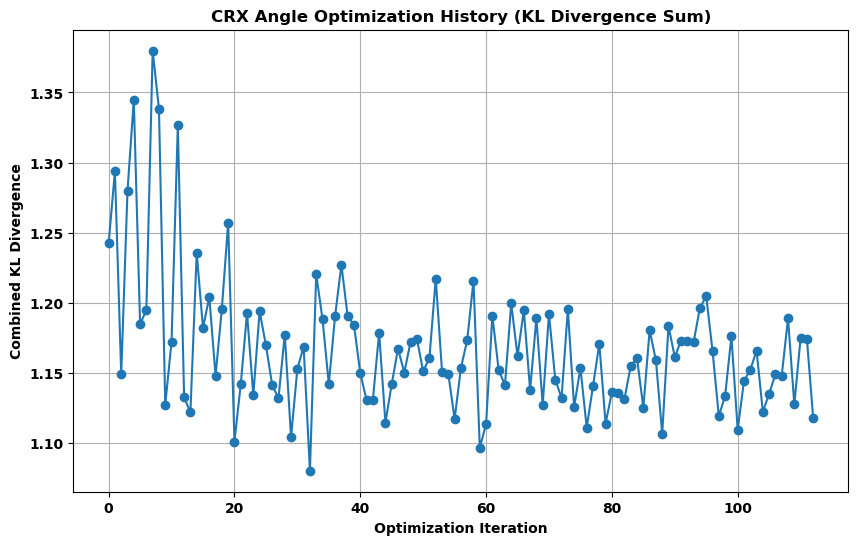


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 2/»
              »
c_measure2: 5/»
              »
«                                                                                                       ┌────────────────────────────────────────────────┐                                                                                        »
«         q_0: ─────────────────────────────────────────────────────────────────────────────────────────┤0                                               ├────────────────────────────────────────────────────────────────────────────────────────»
«                                                                                                       │  Initialize(0.67623,0.73246,0.050148,0.060785) │        

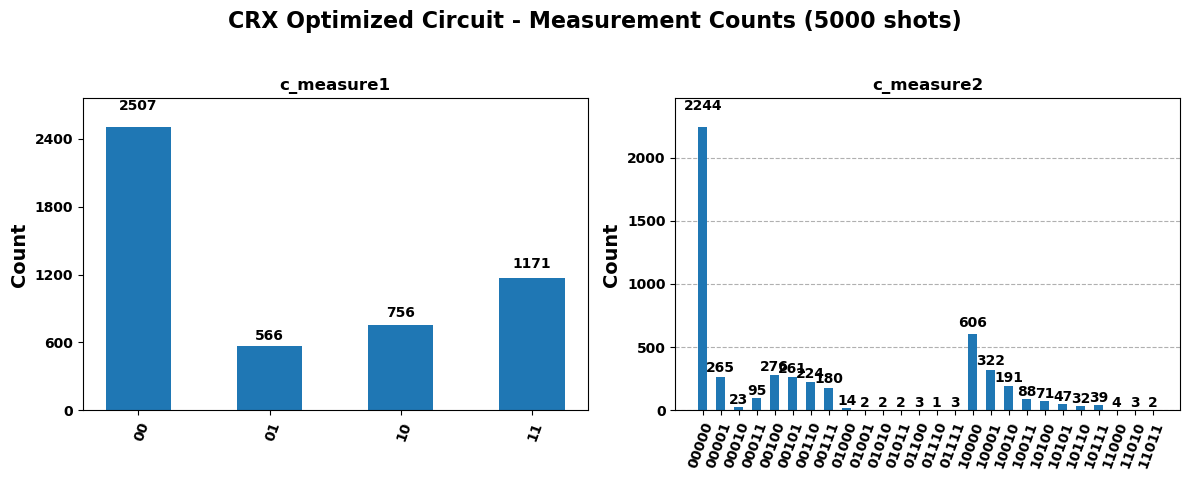

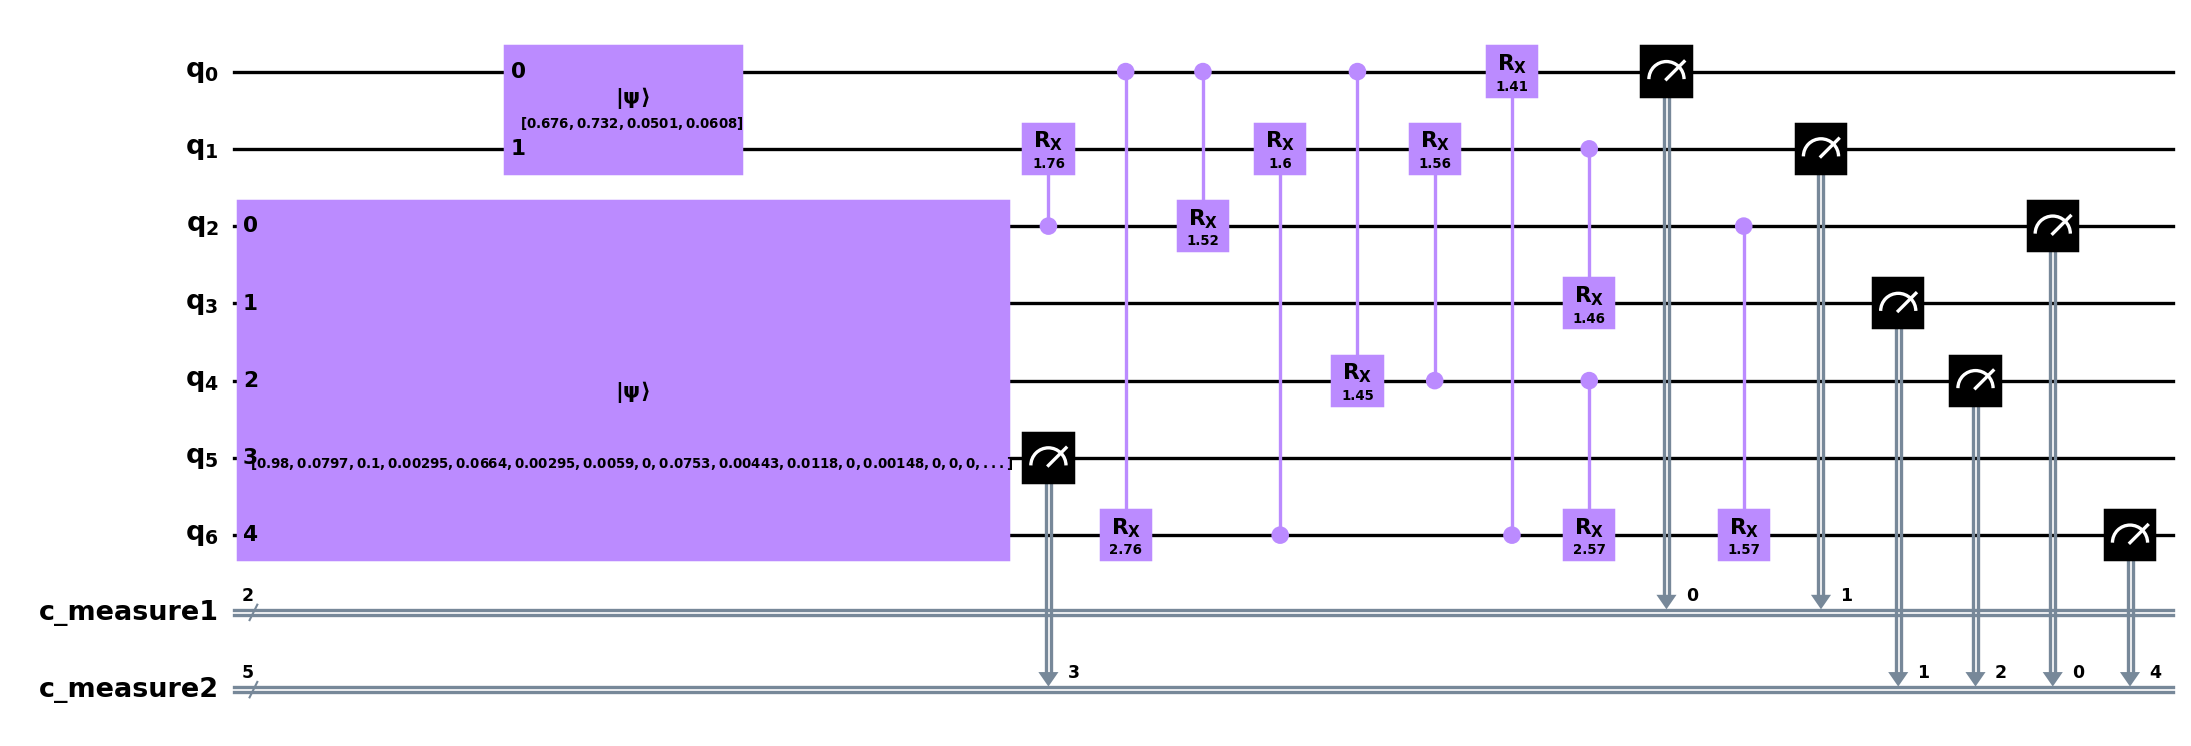

In [38]:
from quantum_functions import optimize_crx_angles, add_crx_gates_and_measurements_to_circuit

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=1.2)

In [ ]:
# ==============================================================================
# --- STAGE 1: RUN QAOA TO GET CANDIDATE SOLUTIONS ---
# ==============================================================================
# This is your existing QAOA setup code
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals
num_qubits = kl_div_mat_qubo.shape[0]
# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")
# Add binary variables: one for each CNOT candidate (0 to 41)
for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')
qp.minimize(quadratic=kl_div_mat_qubo)
# kl_vec = np.diag(kl_div_mat_qubo).copy()
# np.fill_diagonal(kl_div_mat_qubo, 0.0)
#qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)
op, offset = qp.to_ising()
print("offset: {}".format(offset))
print(qp.prettyprint())
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2
algorithm_globals.random_seed = 10598
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=AerSimulator())
qaoa_set = QAOA(
    sampler=SamplerV2(seed=123, default_shots=2000),
    optimizer=COBYLA(maxiter=200),
    initial_point=[1, 1],
    pass_manager=pass_manager,
    reps=1
)
meo_set = MinimumEigenOptimizer(qaoa_set)
qaoa_result = meo_set.solve(qp)
print(qaoa_result.prettyprint())


offset: -7.165314516138689
Problem name: CnotOptimization

Minimize
  -0.4945236376537574*x0^2 - 0.05805039029928283*x0*x1
  - 0.050978449571250195*x0*x10 - 0.011816167961912427*x0*x11
  + 0.00040120581128810784*x0*x12 - 0.04486148915696431*x0*x13
  - 0.026751687630166998*x0*x14 - 0.014262714495582252*x0*x15
  - 0.015849707958895287*x0*x16 - 0.017786274767230825*x0*x17
  - 0.028122900815187535*x0*x18 - 0.0029754831124182424*x0*x19
  + 0.011078560961740092*x0*x2 - 0.005561204983755896*x0*x20
  + 0.019667031756323006*x0*x21 - 0.08955445995444355*x0*x22
  - 0.021074212676632786*x0*x23 - 0.06991486111467404*x0*x24
  - 0.046630272039577036*x0*x25 + 0.009809070938782583*x0*x26
  - 0.03269800439590842*x0*x27 + 0.0008968552403985086*x0*x28
  - 0.030464884664255454*x0*x29 - 0.014110493764119436*x0*x3
  + 0.002830698296052425*x0*x4 - 0.2224555616552779*x0*x5
  - 0.3486372772613926*x0*x6 - 0.1266339652462003*x0*x7
  - 0.34227448204142163*x0*x8 - 0.37570094098728823*x0*x9
  - 0.5095608032642818*x1

In [ ]:
# CORRECTED HELPER FUNCTION
from qiskit_optimization.algorithms import SolutionSample 
from typing import List, Dict

def convert_qaoa_samples_to_counts(
    samples: List[SolutionSample], 
    total_shots_equivalent: int = 10000
) -> Dict[str, int]:
    """
    Converts a list of QAOA SolutionSample objects into a VQE-style counts dictionary.

    This is necessary to use the QAOA results with functions designed for VQE/Sampler output.
    It preserves the relative probabilities of the solutions by converting them to integer counts.

    Args:
        samples (List[SolutionSample]): The list of samples from a Qiskit Optimization result.
        total_shots_equivalent (int): A scaling factor to convert probabilities into
                                      integer counts. The exact value doesn't matter as
                                      long as it preserves the order.

    Returns:
        Dict[str, int]: A dictionary where keys are big-endian bitstrings and values are
                        the corresponding "counts", compatible with the hybrid search function.
    """
    qaoa_counts = {}
    for s in samples:
        # QAOA sample.x is an array like [1., 0., 1.]. Convert to a string '101'.
        # We reverse it to create a big-endian string '101' -> ...x2x1x0, which is
        # a common Qiskit convention and consistent with our VQE helpers.
        bitstring = "".join(str(int(v)) for v in reversed(s.x))
        
        # Convert the solution's probability to an integer count
        count = int(s.probability * total_shots_equivalent)
        
        # Only add solutions with a non-zero chance
        if count > 0:
            qaoa_counts[bitstring] = count
            
    return qaoa_counts

In [ ]:
# ==============================================================================
# --- STAGE 2: CONVERT QAOA RESULTS AND RUN HYBRID SEARCH ---
# ==============================================================================

# 1. Convert the QAOA samples list into a VQE-style counts dictionary
qaoa_counts = convert_qaoa_samples_to_counts(qaoa_result.samples)
print(f"\nConverted QAOA results into a counts dictionary with {len(qaoa_counts)} entries.")

# 2. Call the main hybrid search function, using the QAOA counts as input
best_cnot_sequence, min_kl_sum, best_solution_rank = run_vqe_hybrid_search(
    vqe_counts=qaoa_counts,  # <-- Using the converted QAOA results here!
    initial_cnot_config=initial_cnot_config,
    circ1=circ1,
    circ2=circ2,
    state_probs_initial1=normalized_joint_counts_ct1_mo,
    state_probs_initial2=normalized_joint_counts_ct2_mo,
    state_vec_probs_target1=normalized_joint_counts_ct1_co,
    state_vec_probs_target2=normalized_joint_counts_ct2_co,
    num_solutions_to_test=3,  # We will test the top 3 solutions from QAOA
    nshots=5000,
    threshold=thresh,
    kl_tol=0.1,
    ratio_kl_tol=0.6,
    max_greedy_depth=30,
    min_cnot_depth=1 # You can adjust this as needed
)

# ==============================================================================
# --- STAGE 3: DISPLAY THE FINAL, OVERALL BEST SOLUTION ---
# ==============================================================================
print("\n" + "="*60)
print("--- OVERALL BEST SOLUTION AFTER QAOA + HYBRID SEARCH ---")
print("="*60)

if best_solution_rank is not None:
    print(f"The best solution originated from the QAOA's result at Rank {best_solution_rank}.")
    print(f"\nFinal optimal CNOT sequence found with {len(best_cnot_sequence)} CNOTs:")
    if best_cnot_sequence:
        for cnot in best_cnot_sequence:
            print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    else:
        print("  (The best solution found was to use no CNOTs)")

    print(f"\nWith a minimum combined KL Divergence of: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("No QAOA solution led to a greedy search result that improved upon the initial baseline.")
    print("The best configuration is the baseline circuit with no CNOTs.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))

print("="*60 + "\n")


Converted QAOA results into a counts dictionary with 50 entries.
--- Preparing to test Top 3 VQE solutions in REVERSE order ---

--- Testing VQE Solution (Rank 3/3) ---
This VQE Solution corresponds to a candidate subset of 4 CNOTs:
  q[0] -> q[3]
  q[3] -> q[0]
  q[3] -> q[4]
  q[3] -> q[6]

Setting number of greedy search epochs to 4 (one for each candidate).

--- Starting Multi-Epoch Refined Search ---

--- Using provided CNOT candidate list for the search. ---
Number of candidates to be searched: 4
Initial KL divergence (baseline): 4.789146

--- Starting Epoch 1/4 (Addition) with CNOT: (0, 3) (KL: 4.819736) ---
  Skipping epoch: Single CNOT KL (4.819736) does not improve over baseline (4.789146).

--- Starting Epoch 2/4 (Addition) with CNOT: (3, 6) (KL: 4.847292) ---
  Skipping epoch: Single CNOT KL (4.847292) does not improve over baseline (4.789146).

--- Starting Epoch 3/4 (Addition) with CNOT: (3, 4) (KL: 4.292987) ---
    --> Found a better KL on this path: 2.183854 at depth 


--- Running circuit for: VQE + Epoch search Optimized Circuit ---
Counts for c_measure1: {'1001': 4227, '1000': 35, '1111': 413, '0000': 236, '0110': 23, '1011': 41, '1101': 19, '1110': 2, '0001': 2, '0100': 2}
Counts for c_measure2: {'101': 4496, '000': 245, '111': 177, '100': 41, '001': 28, '010': 11, '011': 1, '110': 1}


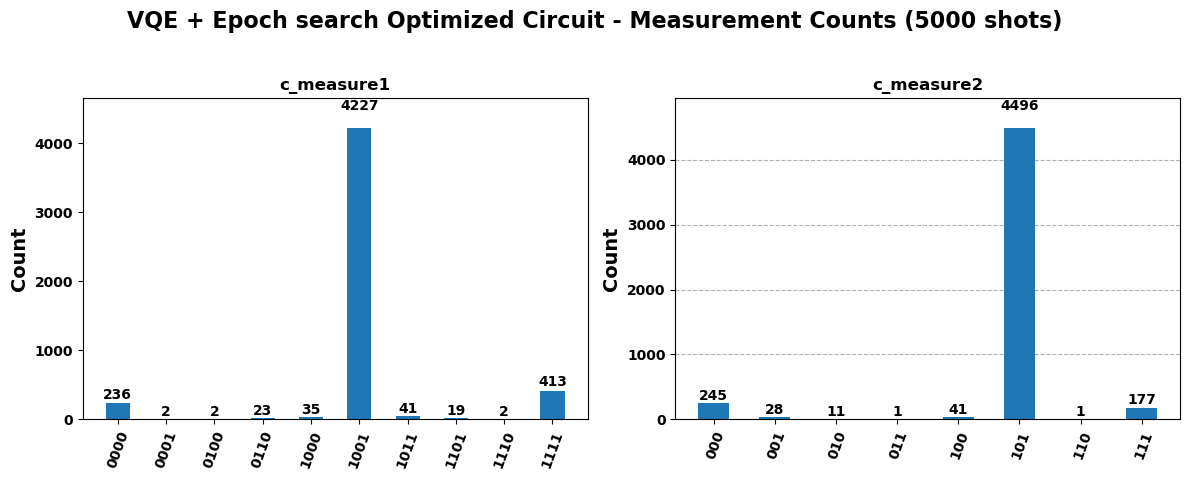

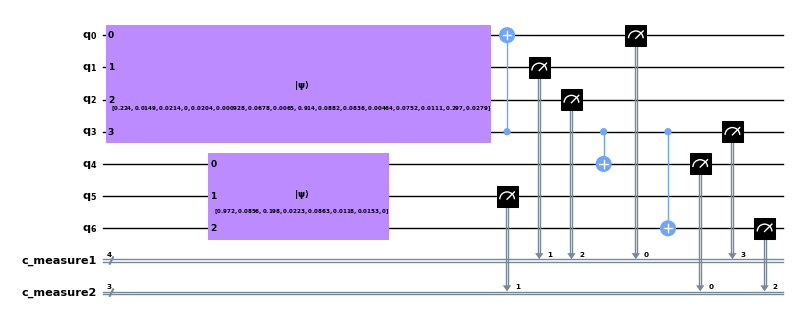

In [ ]:
# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_best_circuit_search, nshots=5000, title_prefix="VQE + Epoch search Optimized Circuit")
final_best_circuit_search
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)